# Gym demo

Demonstrate the use of the the Gym interface

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)



## Load config file

In [2]:
config = OmegaConf.load("config.yml")

# Create env object

In [3]:
env = assettoCorsa.make_ac_env(cfg=config, work_dir="output")


2026-04-07 16:46:24 - AssettoCorsaEnv.ac_env - INFO - Setting track ks_barcelona-layout_gp
2026-04-07 16:46:24 - AssettoCorsaEnv.ac_client - WARNING - Controls will be executed locally and not by the server
2026-04-07 16:46:28 - AssettoCorsaEnv.track - INFO - Track loaded from: /home/wyb/car/assetto_corsa_gym/assetto_corsa_gym/AssettoCorsaEnv/../AssettoCorsaConfigs/tracks/ks_barcelona-layout_gp.csv Found 3000 segments downsampled by 10= 300 segments
2026-04-07 16:46:28 - AssettoCorsaEnv.reference_lap - INFO - Reference Lap. Loading: /home/wyb/car/assetto_corsa_gym/assetto_corsa_gym/AssettoCorsaEnv/../AssettoCorsaConfigs/tracks/ks_barcelona-layout_gp-racing_line_fixed.csv
2026-04-07 16:46:28 - AssettoCorsaEnv.reference_lap - INFO - Using curvature from racing line file
2026-04-07 16:46:28 - AssettoCorsaEnv.sensors_ray_casting - INFO - spatial_hash len 109
/home/wyb/anaconda3/envs/acgym/lib/python3.10/site-packages/gym/spaces/box.py:73: UserWarning: WARN: Box bound precision lowered by c

# Show static info

In [4]:
static_info = env.client.simulation_management.get_static_info()
ac_mod_config = env.client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


2026-04-07 16:46:28 - __main__ - INFO - Static info:
2026-04-07 16:46:28 - __main__ - INFO - WindSpeed: 0
2026-04-07 16:46:28 - __main__ - INFO - isCarInPit: 0
2026-04-07 16:46:28 - __main__ - INFO - TrackConfiguration: layout_gp
2026-04-07 16:46:28 - __main__ - INFO - penaltiesEnabled: 1
2026-04-07 16:46:28 - __main__ - INFO - WorldPosition: [172.05679321289062, 2.5284998416900635, -538.3160400390625]
2026-04-07 16:46:28 - __main__ - INFO - isCarInPitlane: 0
2026-04-07 16:46:28 - __main__ - INFO - CarName: bmw_z4_gt3
2026-04-07 16:46:28 - __main__ - INFO - TrackLength: 4591.88720703125
2026-04-07 16:46:28 - __main__ - INFO - WindDirection: 359
2026-04-07 16:46:28 - __main__ - INFO - TyreContactPoint_RL: [170.4910430908203, 2.173794746398926, -538.1211547851562]
2026-04-07 16:46:28 - __main__ - INFO - LastSplits: [0, 0, 0]
2026-04-07 16:46:28 - __main__ - INFO - TyreContactPoint_FR: [173.4735565185547, 2.104072093963623, -538.4340209960938]
2026-04-07 16:46:28 - __main__ - INFO - CAR_T

# Apply actions and recover the car

In [5]:
states = []

env.reset()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    env.set_actions(np.array([steer, 0.1, -1.]))
    next_state, reward, done, info = env.step(action=None)  # action is already applied
    if done:
        break

env.recover_car()
env.close()

2026-04-07 16:46:28 - AssettoCorsaEnv.ac_env - INFO - Reset AC. Episode 1 total_steps: 0
2026-04-07 16:46:29 - AssettoCorsaEnv.ac_client - INFO - sending reset to simulation management server
2026-04-07 16:46:30 - AssettoCorsaEnv.ac_client - INFO - AC Client. Listening at host: localhost port: 2345
2026-04-07 16:46:30 - AssettoCorsaEnv.ac_client - INFO - Client connected on 2345
2026-04-07 16:46:33 - AssettoCorsaEnv.ac_env - INFO - Terminate episode. is_out_of_track
2026-04-07 16:46:33 - AssettoCorsaEnv.ac_env - INFO - out_of_track. N wheels out: 3. LapDist: 3882.274190245662 x: -533.31 y: 152.32
2026-04-07 16:46:33 - AssettoCorsaEnv.ac_env - INFO - Recover car
2026-04-07 16:46:33 - AssettoCorsaEnv.ac_client - INFO - sending reset to simulation management server
2026-04-07 16:46:34 - AssettoCorsaEnv.ac_env - INFO - Saved raw data to: output/laps//20260407_164634.569_states.parquet
2026-04-07 16:46:34 - AssettoCorsaEnv.ac_env - INFO - total_steps: 81 ep_steps: 78 ep_reward:    3.4 LapDi

{'ep_count': 1,
 'ep_steps': 79,
 'total_steps': 81,
 'packages_lost': 0,
 'ep_reward': 3.4290960696217114,
 'speed_mean': 3.9808783666595455,
 'speed_max': 9.448288917541504,
 'BestLap': 0.0,
 'terminated': True,
 'LapNo_0': 0.0,
 'ep_bestLapTime': 0}

# Plot states

In [6]:
df = env.get_history()
df.columns

Index(['done', 'rl_tire_temperature_core', 'rr_tire_pressure',
       'rr_damper_linear_potentiometer', 'tyre_slip_ratio_rr', 'roll',
       'tyreContactHeading_RR_z', 'tyreContactHeading_RR_x',
       'tyreContactHeading_RR_y', 'rl_damper_linear_potentiometer',
       ...
       'going_backwards', 'terminated', 'TimeLimit.truncated',
       'current_action_abs_0', 'current_action_abs_1', 'current_action_abs_2',
       'actions_0', 'actions_1', 'actions_2', 'reward'],
      dtype='object', length=110)

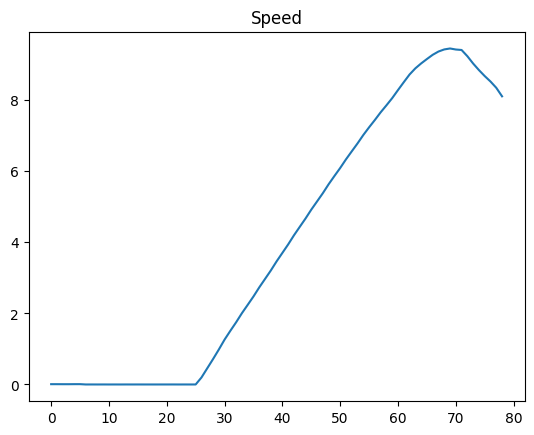

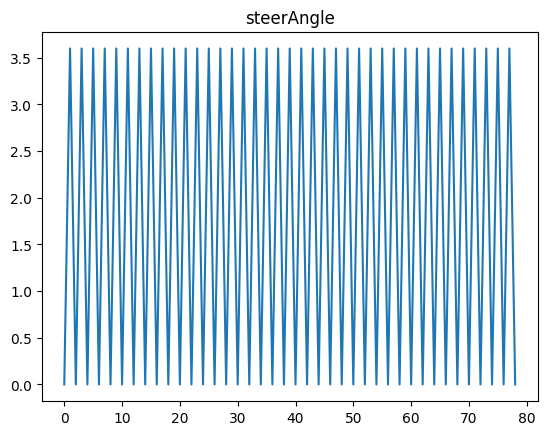

In [7]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()